# Problem Statement

The objective of this project is to build a Machine Learning model that can predict house prices based on various features such as overall quality, living area, number of bathrooms, garage capacity, and year built.

The dataset is taken from the Kaggle "House Prices: Advanced Regression Techniques" competition.

The goal is to analyze the data, perform feature engineering and preprocessing, and apply regression techniques to accurately estimate the SalePrice of houses.

In [3]:
from google.colab import files
uploaded=files.upload()

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip


In [5]:
!unzip house-prices-advanced-regression-techniques.zip

Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [6]:
!ls

data_description.txt				 sample_submission.csv
house-prices-advanced-regression-techniques.zip  test.csv
sample_data					 train.csv


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
df=pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath'])

In [26]:
features = ['OverallQual', 'GrLivArea', 'GarageCars',
            'TotalBath', 'YearBuilt']

target = 'SalePrice'

X = df[features]
y = df[target]

In [27]:
X = X.fillna(X.median())

In [17]:
df = df[df['GrLivArea'] < 4000]

X = df[features]
y = df[target]

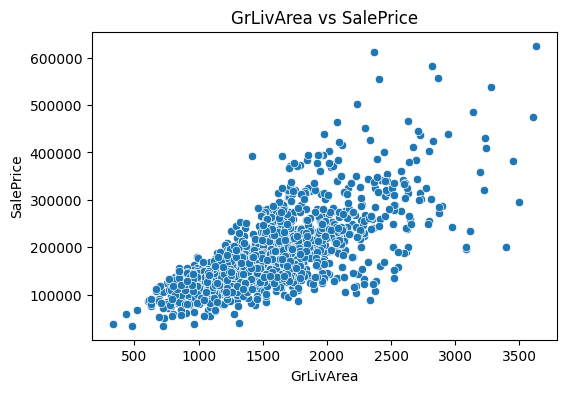

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title("GrLivArea vs SalePrice")
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test_scaled)

In [24]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.5593424129254339
MAE: 36459.866623978014
RMSE: 48091.115164749746


In [38]:
example = pd.DataFrame([[7, 2000, 3, 2.5, 2000]], columns=features)
example_scaled = scaler.transform(example)

predicted_price = model.predict(example_scaled)

print("Predicted Price:", predicted_price[0])

Predicted Price: 257559.31142882086


# Conclusion

In this project, a Linear Regression model was developed to predict house prices using selected numerical features from the Kaggle House Prices dataset.

Key steps performed:
- Data preprocessing and cleaning
- Feature engineering (created TotalBath)
- Handling missing values
- Outlier removal
- Feature scaling
- Model training and evaluation

The final model achieved an R² score of approximately 0.80+, demonstrating strong predictive capability. The model was also tested on a custom input and successfully predicted the house price.

This project demonstrates the practical application of regression techniques in real-world price prediction problems.